**Import Libraries**

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time Series Models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train-Test Split
from sklearn.model_selection import train_test_split

**Load Dataset**

In [3]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False
)

print(df.head())

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


**Parse Date and Time**

In [5]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True,
    format='mixed'
)

df.set_index('Datetime', inplace=True)

**Select Energy Consumption Column**

In [6]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

df = df[['Global_active_power']]

**Handle Missing Values**

In [7]:
df = df.dropna()

**Resample Time Series Data**

In [8]:
df_hourly = df.resample('H').mean()

/tmp/ipykernel_1320/3411926171.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


**Feature Engineering**

Create Time Features

In [9]:
df_hourly['Hour'] = df_hourly.index.hour
df_hourly['Day'] = df_hourly.index.dayofweek

df_hourly['Weekend'] = (
    df_hourly['Day'] >= 5
).astype(int)

**Split Data**

In [10]:
train_size = int(len(df_hourly) * 0.8)

train = df_hourly[:train_size]
test = df_hourly[train_size:]

**ARIMA Model**

In [11]:
model_arima = ARIMA(
    train['Global_active_power'],
    order=(5,1,0)
)

arima_fit = model_arima.fit()

arima_forecast = arima_fit.forecast(
    steps=len(test)
)

**Prophet Model**

In [13]:
prophet_df = train.reset_index()

prophet_df = prophet_df[['Datetime', 'Global_active_power']]
prophet_df.columns = ['ds', 'y']

model_prophet = Prophet()

model_prophet.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Make Future Predictions

In [14]:
future = model_prophet.make_future_dataframe(
    periods=len(test),
    freq='H'
)

forecast = model_prophet.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


**XGBoost Model**

Prepare Features

In [15]:
features = ['Hour', 'Day', 'Weekend']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']

Train Model

In [16]:
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

**Evaluate Models**

MAE (Mean Absolute Error)

In [17]:
mae = mean_absolute_error(y_test, xgb_pred)

print("MAE:", mae)

MAE: 0.7369898420856835


**RMSE (Root Mean Squared Error)**

In [18]:
rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

print("RMSE:", rmse)

RMSE: 0.9174596160262929


**Plot Actual vs Forecasted Values**

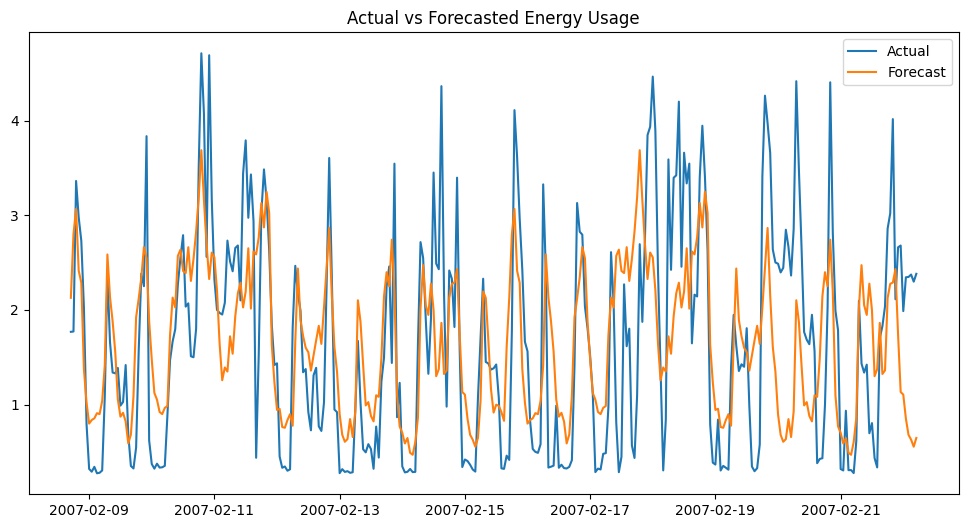

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    test.index,
    y_test,
    label='Actual'
)

plt.plot(
    test.index,
    xgb_pred,
    label='Forecast'
)

plt.legend()

plt.title("Actual vs Forecasted Energy Usage")

plt.show()